# The concurrency envelope: GPU flood beside CPU loads

**What this notebook shows.** The optimized flood kernel exists so the
Raspberry Pi 5's idle GPU can run a real-time simulation while the CPU
does other work; the two share one LPDDR memory bus, so the interference
must be measured. This notebook derives, from committed raw logs:

1. steady-state throughput of each flood kernel alone and beside LLM
   decode (the paper's Table IV);
2. the CPU-only counterfactual under the same protocol (Table V);
3. GPU and CPU retention under generic (non-LLM) CPU loads;
4. the device-visibility decode A/B.

**Protocol.** Concurrent and decode-alone phases are measured only after
a decode soak reaches the firmware's governed thermal regime (74 to 76 C,
soft-limit bit active), over llama-bench tg64 r=20 windows; a flood run
counts only if it starts and finishes inside the window. Generic-load
pairings use continuous sim-mode GPU probes over cool-start 60 s windows.
The windowing rule shared with the paper lives in
`../pi/flood/analyze_conc_bench.py`; this notebook reuses it and
re-derives key numbers independently with `analysis_utils.py`.

**Data provenance.** All inputs are unmodified logs under
`../docs/paper/artifacts/`, produced on the board:

| Directory | Produced by | Date |
|---|---|---|
| `conc_steady_2026-08-10/` | `pi/flood/conc_steady_bench.sh` | 2026-08-10 |
| `cpu_steady_2026-08-10/` | `pi/flood/cpu_steady_bench.sh` | 2026-08-10 |
| `genload2_2026-08-10/` | `pi/flood/genload2_bench.sh` | 2026-08-10 |
| `ab_vkvisible_2026-08-10/` | `run_script.sh` (archived in the directory) | 2026-08-10 |
| `conc_bench2/`, `cpu_flood_bench2/` | earlier short-window (thermal-transient) campaign, kept for comparison | 2026-07-12 |

This notebook supports Section VII, Tables IV and V, of
`../docs/paper/paper.pdf`. It runs offline.

In [1]:
import statistics, subprocess, sys
from pathlib import Path

import analysis_utils as au

ART = Path("../docs/paper/artifacts")
def analyze(d, steps=4000):
    out = subprocess.run([sys.executable, "../pi/flood/analyze_conc_bench.py", str(d), str(steps)],
                         capture_output=True, text=True)
    print(out.stdout)

print("=== steady-state campaign (Table IV) ===")
analyze(ART / "conc_steady_2026-08-10")
print("=== earlier transient-window campaign, for comparison ===")
analyze(ART / "conc_bench2")

=== steady-state campaign (Table IV) ===
flood opt alone                              2128.0 ±   1.7 steps/s  (n=3)
flood orig alone                             1351.4 ±   0.5 steps/s  (n=3)
flood opt under CPU decode                    883.4 ±  47.1 steps/s  (n=28)
flood orig under CPU decode                   401.8 ±   8.3 steps/s  (n=12)
llama alone                                    11.4 ±   0.0 t/s     (n=5)
llama alone soak                               11.4 ±   0.1 t/s     (n=5)
llama vs opt                                    9.6 ±   0.2 t/s     (n=5)
llama vs opt soak                              10.2 ±   0.2 t/s     (n=5)
llama vs orig                                   9.6 ±   0.2 t/s     (n=5)
llama vs orig soak                              9.9 ±   0.2 t/s     (n=5)

thermal validity (max temp / samples with throttle ACTIVE):
  thermal_end.log                    max  74.7 C  TAINTED (1 throttled samples)
  thermal_llama_alone.log            max  73.0 C  TAINTED (5 throttled s

The steady campaign is the paper's Table IV: the GPU keeps 42% of its
solo rate beside decode (883.4 / 2,128.0), decode keeps 84% (9.6 / 11.4),
and the optimized kernel's concurrent advantage is 883.4 / 401.8 = 2.20x.
The transient campaign, whose windows never reached the governed regime,
reads up to 19% differently in both directions. The thermal audit above
also shows the optimized-kernel window still drifting upward within its
window; the reported mean is conservative.

## 2. The CPU-only counterfactual (Table V)

In [2]:
C = ART / "cpu_steady_2026-08-10"
print("Table V (steady-state counterfactual)")
for t in (1, 2, 4):
    print(f"  CPU flood {t}t alone      ", au.fmt(au.sps(C / f"flood_cpu{t}t_alone.log")), "steps/s")
print("  decode 3t alone (soaked)", au.tps(C / "llama_t3_alone.log"), "t/s")
print("  partitioned flood       ", au.fmt(au.windowed(C / "flood_cpu1part_conc.log")), "steps/s")
print("  partitioned decode      ", au.tps(C / "llama_vs_cpu1part.log"), "t/s")
print("  oversubscribed flood    ", au.fmt(au.windowed(C / "flood_cpu4over_conc.log")), "steps/s")
print("  oversubscribed decode   ", au.tps(C / "llama_vs_cpu4over.log"), "t/s")

Table V (steady-state counterfactual)
  CPU flood 1t alone          992.5 ±    0.6  (n=3) steps/s
  CPU flood 2t alone         1980.5 ±    2.5  (n=3) steps/s
  CPU flood 4t alone         3852.4 ±   15.4  (n=3) steps/s
  decode 3t alone (soaked) 11.90 ± 0.01 t/s
  partitioned flood           678.8 ±   10.6  (n=25) steps/s
  partitioned decode       8.41 ± 0.05 t/s
  oversubscribed flood        857.1 ±  181.0  (n=89) steps/s
  oversubscribed decode    2.97 ± 0.33 t/s


The GPU split (883.4 ± 47.1 steps/s beside 9.6 ± 0.2 t/s) beats the
partitioned CPU-only best on both axes: +30% simulation, +14% decode.

## 3. Generic CPU loads

Both sides of every pairing, from `genload2_2026-08-10/`.

In [3]:
G = ART / "genload2_2026-08-10"
ga = au.windowed(G / "gpu_alone_gpu.log", "window_start", "window_end")
go = au.windowed(G / "openssl_pair_gpu.log", "window_start", "window_end")
gc = au.windowed(G / "cpuflood_pair_gpu.log", "window_start", "window_end")
ca = au.sps(G / "cpuflood_alone.log")
cc = au.windowed(G / "cpuflood_pair_cpu.log", "window_start", "window_end")
base = statistics.mean(ga)
print("GPU alone                 ", au.fmt(ga))
print("GPU + openssl 4t          ", au.fmt(go), f" GPU keeps {statistics.mean(go)/base*100:5.1f}%")
print("GPU + cpuflood 4t         ", au.fmt(gc), f" GPU keeps {statistics.mean(gc)/base*100:5.1f}%")
print("cpuflood alone            ", au.fmt(ca))
print("cpuflood beside GPU       ", au.fmt(cc), f" load keeps {statistics.mean(cc)/statistics.mean(ca)*100:5.1f}%")
import re
ossl = {}
for tag, f in (("alone", "openssl_alone.log"), ("paired", "openssl_pair_cpu.log")):
    ossl[tag] = float(re.findall(r"sha256\s+(.*)", (G / f).read_text())[-1].split()[-1].rstrip("k"))
print(f"openssl 16KB-block alone {ossl['alone']/1e6:.2f} GB/s, beside GPU {ossl['paired']/1e6:.2f} GB/s"
      f" (load keeps {ossl['paired']/ossl['alone']*100:.1f}%)")

GPU alone                    2126.0 ±    1.9  (n=30)
GPU + openssl 4t             2106.3 ±    7.2  (n=149)  GPU keeps  99.1%
GPU + cpuflood 4t            1953.4 ±   26.8  (n=27)  GPU keeps  91.9%
cpuflood alone               3831.2 ±   69.3  (n=57)
cpuflood beside GPU          2862.4 ±  291.8  (n=42)  load keeps  74.7%
openssl 16KB-block alone 5.97 GB/s, beside GPU 5.25 GB/s (load keeps 87.8%)


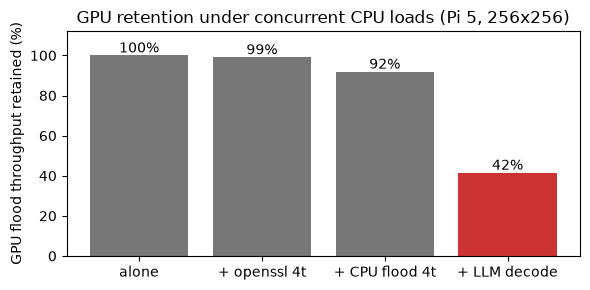

In [4]:
import matplotlib.pyplot as plt

labels = ["alone", "+ openssl 4t", "+ CPU flood 4t", "+ LLM decode"]
retained = [100,
            statistics.mean(go) / base * 100,
            statistics.mean(gc) / base * 100,
            883.4 / 2128.0 * 100]
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(labels, retained, color=["#777"] * 3 + ["#c33"])
ax.set_ylabel("GPU flood throughput retained (%)")
ax.set_title("GPU retention under concurrent CPU loads (Pi 5, 256x256)")
for i, v in enumerate(retained):
    ax.text(i, v + 1.5, f"{v:.0f}%", ha="center")
ax.set_ylim(0, 112)
plt.tight_layout()
plt.savefig("gpu_retention.png", dpi=120)
plt.show()

The GPU is the robust side of every pairing except decode, which
streams model weights from DRAM every token: interference tracks the CPU
load's memory traffic, not its core count.

## 4. The device-visibility A/B

With any Vulkan device visible, llama.cpp places CPU-resident model
weights in host-pinned, write-combined GPU memory even at `-ngl 0`,
which is slow for the CPU reads that dominate decode. Both runs from
cool starts, invocation archived beside the logs:

In [5]:
A = ART / "ab_vkvisible_2026-08-10"
for tag in ("visible", "hidden"):
    line = [l for l in (A / f"{tag}.log").read_text().splitlines() if "tg64" in l][0]
    print(f"{tag:8s}", line.split("|")[-2].strip(), "t/s")
vis, hid = (float([l for l in (A / f"{t}.log").read_text().splitlines() if "tg64" in l][0]
                  .split("|")[-2].split("\u00b1")[0]) for t in ("visible", "hidden"))
print(f"\ngain from hiding the device: {hid/vis*100-100:.1f}%")

visible  9.68 ± 0.00 t/s
hidden   11.59 ± 0.00 t/s

gain from hiding the device: 19.7%


## Rerunning live

```
# on the Pi
OUT=/tmp/conc_steady bash pi/flood/conc_steady_bench.sh
OUT=/tmp/cpu_steady bash pi/flood/cpu_steady_bench.sh
OUT=/tmp/genload2 bash pi/flood/genload2_bench.sh
OUT=/tmp/ab bash pi/flood/ab_vkvisible_bench.sh
python3 pi/flood/analyze_conc_bench.py /tmp/conc_steady 4000
```

## Environment

In [6]:
au.environment()

python 3.14.3
matplotlib 3.11.1


nbformat 5.11.0
